# Practice Exercise: Cleaning data & Transforming columns/features

## Context:
- The data is based on real anonymized Czech bank transactions and account info.
- We'll be focusing on practicing the data cleaning, columns transformations, and other techniques that we've learned in the course.
- But here is the original task description of the dataset publishers:

*The bank wants to improve their services. For instance, the bank managers have only vague idea, who is a good client (whom to offer some additional services)   and who is a bad client (whom to watch carefully to minimize the bank losses). Fortunately, the bank stores data about their clients, the accounts (transactions within several months), the loans already granted, the credit cards issued. The bank managers hope to improve their understanding of customers and seek specific actions to improve services.*



## Dataset Description:

We'll work on three datasets (in three separate csv files):

  - **account**: each record describes static characteristics of an account
  - **transaction**: each record describes one transaction on an account
  - **district**: each record describes demographic characteristics of a district
  
In reality, the organizations like banks often have data stored in multiple datasets. Assume we want to study the transactional level data, we'll need to combine these three datasets together to have transactions data with account and district data.

## Objective:
   - Examine/clean the individual dataset
   - Combine them into a single dataset, which is subject to more cleaning
   - Create new columns based on existing columns

By the end, the new dataset is ready for more analysis.

### 1. Import the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Import the data from three csv files as DataFrames `account`, `district`, `trans`
Hint:
- the `read_csv` function can automatically infer and load zip file, read its documentation of parameter `compression` if you are interested in details
- you may ignore the warning when reading the `trans.csv.zip` file. It is optional to follow the warning instructions to remove it.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
account = pd.read_csv('/content/drive/MyDrive/account.csv')
district = pd.read_csv('/content/drive/MyDrive/district.csv')
trans = pd.read_csv('/content/drive/MyDrive/trans.csv')

<ipython-input-3-a650b153b24e>:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  trans = pd.read_csv('/content/drive/MyDrive/trans.csv')


### 3. Look at the info summary, head of each DataFrame

In [ ]:
print(account.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   account_id         4500 non-null   int64 
 1   district_id        4500 non-null   int64 
 2   frequency          4500 non-null   object
 3   account_open_date  4500 non-null   object
 4   client_id          4500 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 175.9+ KB
None


In [ ]:
print(account.head())

   account_id  district_id           frequency account_open_date  client_id
0         576           55  MONTHLY STATEMENTS        1993-01-01        692
1        3818           74  MONTHLY STATEMENTS        1993-01-01       4601
2         704           55  MONTHLY STATEMENTS        1993-01-01        844
3        2378           16  MONTHLY STATEMENTS        1993-01-01       2873
4        2632           24  MONTHLY STATEMENTS        1993-01-02       3177


In [ ]:
print(district.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   district_id           76 non-null     int64  
 1   district_name         76 non-null     object 
 2   region                76 non-null     object 
 3   population            76 non-null     int64  
 4   average_salary        66 non-null     float64
 5   unemployment_rate     66 non-null     float64
 6   num_committed_crimes  67 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 4.3+ KB
None


In [ ]:
print(district.head())

   district_id district_name           region  population  average_salary  \
0            1   Hl.m. Praha           Prague     1204953         12541.0   
1            2       Benesov  central Bohemia       88884             NaN   
2            3        Beroun  central Bohemia       75232          8980.0   
3            4        Kladno  central Bohemia      149893          9753.0   
4            5         Kolin  central Bohemia       95616          9307.0   

   unemployment_rate  num_committed_crimes  
0               0.43               99107.0  
1                NaN                2674.0  
2               2.21                2813.0  
3               5.05                   NaN  
4               4.43                   NaN  


In [ ]:
print(trans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   trans_id         1056320 non-null  int64  
 1   account_id       1056320 non-null  int64  
 2   date             1056320 non-null  object 
 3   type             1056320 non-null  object 
 4   operation_type   873206 non-null   object 
 5   amount           1056320 non-null  float64
 6   balance          1056320 non-null  float64
 7   description      574439 non-null   object 
 8   partner_bank     273508 non-null   object 
 9   partner_account  295389 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 80.6+ MB
None


In [ ]:
print(trans.head())

   trans_id  account_id        date    type  operation_type  amount  balance  \
0    695247        2378  1993-01-01  CREDIT  CREDIT IN CASH   700.0    700.0   
1    171812         576  1993-01-01  CREDIT  CREDIT IN CASH   900.0    900.0   
2    207264         704  1993-01-01  CREDIT  CREDIT IN CASH  1000.0   1000.0   
3   1117247        3818  1993-01-01  CREDIT  CREDIT IN CASH   600.0    600.0   
4    579373        1972  1993-01-02  CREDIT  CREDIT IN CASH   400.0    400.0   

  description partner_bank  partner_account  
0         NaN          NaN              NaN  
1         NaN          NaN              NaN  
2         NaN          NaN              NaN  
3         NaN          NaN              NaN  
4         NaN          NaN              NaN  


### 4. Check for the unique values and their counts in each column for the three DataFrames

In [ ]:
print(account.nunique())

account_id           4500
district_id            77
frequency               3
account_open_date    1535
client_id            4500
dtype: int64


In [ ]:
print(account.value_counts())

account_id  district_id  frequency           account_open_date  client_id
1           18           MONTHLY STATEMENTS  1995-03-24         1            1
3153        2            MONTHLY STATEMENTS  1996-07-05         3813         1
3160        22           MONTHLY STATEMENTS  1994-06-19         3821         1
3158        71           MONTHLY STATEMENTS  1996-10-03         3818         1
3157        77           MONTHLY STATEMENTS  1993-09-10         3817         1
                                                                            ..
1585        42           MONTHLY STATEMENTS  1996-02-23         1920         1
1586        1            MONTHLY STATEMENTS  1996-10-03         1921         1
1587        1            MONTHLY STATEMENTS  1996-12-11         1923         1
1588        67           MONTHLY STATEMENTS  1993-12-11         1924         1
11382       74           MONTHLY STATEMENTS  1995-08-20         13998        1
Length: 4500, dtype: int64


In [ ]:
print(district.nunique())

district_id             76
district_name           76
region                   8
population              76
average_salary          65
unemployment_rate       63
num_committed_crimes    66
dtype: int64


In [ ]:
print(district.value_counts())

district_id  district_name        region           population  average_salary  unemployment_rate  num_committed_crimes
1            Hl.m. Praha          Prague           1204953     12541.0         0.43               99107.0                 1
3            Beroun               central Bohemia  75232       8980.0          2.21               2813.0                  1
43           Hradec Kralove       east Bohemia     161854      9425.0          2.50               3891.0                  1
44           Chrudim              east Bohemia     105606      8254.0          3.76               2325.0                  1
46           Nachod               east Bohemia     112709      8369.0          2.31               2618.0                  1
48           Rychnov nad Kneznou  east Bohemia     78955       9060.0          2.44               1717.0                  1
50           Svitavy              east Bohemia     102609      8187.0          5.45               2134.0                  1
51           

In [ ]:
print(trans.nunique())

trans_id           1056320
account_id            4500
date                  2191
type                     2
operation_type           5
amount               40400
balance             542739
description              8
partner_bank            13
partner_account       7665
dtype: int64


In [ ]:
print(trans.value_counts())

trans_id  account_id  date        type    operation_type                amount  balance  description   partner_bank  partner_account
58        1           1995-09-05  DEBIT   REMITTANCE TO ANOTHER BANK    2452.0  19035.3  HOUSEHOLD     YZ            87144583.0         1
892930    3043        1997-08-10  DEBIT   REMITTANCE TO ANOTHER BANK    2768.0  16043.5  HOUSEHOLD     QR            90735184.0         1
893068    3044        1997-11-10  CREDIT  COLLECTION FROM ANOTHER BANK  4134.0  29674.0  PENSION       MN            73289644.0         1
893069    3044        1997-12-10  CREDIT  COLLECTION FROM ANOTHER BANK  4134.0  29879.3  PENSION       MN            73289644.0         1
893070    3044        1998-01-10  CREDIT  COLLECTION FROM ANOTHER BANK  4134.0  25361.4  PENSION       MN            73289644.0         1
                                                                                                                                       ..
454360    1544        1994-10-09  DEBIT

### 5. Check for duplicates in the three DataFrames

In [ ]:
print(account.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
4495    False
4496    False
4497    False
4498    False
4499    False
Length: 4500, dtype: bool


In [ ]:
print(district.duplicated())

0     False
1     False
2     False
3     False
4     False
      ...  
71    False
72    False
73    False
74    False
75    False
Length: 76, dtype: bool


In [ ]:
print(trans.duplicated())

0          False
1          False
2          False
3          False
4          False
           ...  
1056315    False
1056316    False
1056317    False
1056318    False
1056319    False
Length: 1056320, dtype: bool


### 6. Convert column `account_open_date` in `account` and column `date` in `trans` into datetime dtypes

In [ ]:
account['account_open_date'] = pd.to_datetime(account['account_open_date'])

In [ ]:
print(account.head(4))

   account_id  district_id           frequency account_open_date  client_id
0         576           55  MONTHLY STATEMENTS        1993-01-01        692
1        3818           74  MONTHLY STATEMENTS        1993-01-01       4601
2         704           55  MONTHLY STATEMENTS        1993-01-01        844
3        2378           16  MONTHLY STATEMENTS        1993-01-01       2873


In [ ]:
print(account.dtypes)

account_id                    int64
district_id                   int64
frequency                    object
account_open_date    datetime64[ns]
client_id                     int64
dtype: object


In [ ]:
trans['date'] = pd.to_datetime(trans['date'])

In [ ]:
print(trans.head(4))

   trans_id  account_id       date    type  operation_type  amount  balance  \
0    695247        2378 1993-01-01  CREDIT  CREDIT IN CASH   700.0    700.0   
1    171812         576 1993-01-01  CREDIT  CREDIT IN CASH   900.0    900.0   
2    207264         704 1993-01-01  CREDIT  CREDIT IN CASH  1000.0   1000.0   
3   1117247        3818 1993-01-01  CREDIT  CREDIT IN CASH   600.0    600.0   

  description partner_bank  partner_account  
0         NaN          NaN              NaN  
1         NaN          NaN              NaN  
2         NaN          NaN              NaN  
3         NaN          NaN              NaN  


In [ ]:
print(trans.dtypes)

trans_id                    int64
account_id                  int64
date               datetime64[ns]
type                       object
operation_type             object
amount                    float64
balance                   float64
description                object
partner_bank               object
partner_account           float64
dtype: object


### 7. Convert the columns `region` and `district_name` in `district` to all uppercase

In [ ]:
district['region'] = district['region'].str.upper()

In [ ]:
district['district_name'] = district['district_name'].str.upper()

In [ ]:
print(district.head())

   district_id district_name           region  population  average_salary  \
0            1   HL.M. PRAHA           PRAGUE     1204953         12541.0   
1            2       BENESOV  CENTRAL BOHEMIA       88884             NaN   
2            3        BEROUN  CENTRAL BOHEMIA       75232          8980.0   
3            4        KLADNO  CENTRAL BOHEMIA      149893          9753.0   
4            5         KOLIN  CENTRAL BOHEMIA       95616          9307.0   

   unemployment_rate  num_committed_crimes  
0               0.43               99107.0  
1                NaN                2674.0  
2               2.21                2813.0  
3               5.05                   NaN  
4               4.43                   NaN  


### 8. Check for missing data by columns in `account` using the `isna` method

In [ ]:
account.isna()

,account_id,district_id,frequency,account_open_date,client_id
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
4495,False,False,False,False,False
4496,False,False,False,False,False
4497,False,False,False,False,False
4498,False,False,False,False,False


In [ ]:
account.isna().sum()

account_id           0
district_id          0
frequency            0
account_open_date    0
client_id            0
dtype: int64

### 9. Check for missing data by columns in `district` using the `isna` method

In [ ]:
district.isna()

,district_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,False,False,False,False,False,False,False
1,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True
4,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...
71,False,False,False,False,True,False,False
72,False,False,False,False,False,False,False
73,False,False,False,False,False,False,False
74,False,False,False,False,False,False,False


In [ ]:
district.isna().sum()

district_id              0
district_name            0
region                   0
population               0
average_salary          10
unemployment_rate       10
num_committed_crimes     9
dtype: int64

`district` has numeric features that could have relationships with each other. Let's use iterative imputation on them.

#### Use `IterativeImputer` in `sklearn` to impute based on columns `population`, `average_salary`, `unemployment_rate`, `num_committed_crimes`

##### Import libraries

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

##### Build a list of columns that will be used for imputation, which are `population`, `average_salary`, `unemployment_rate`, `num_committed_crimes`
These are the columns that might be related to each other

In [ ]:
district_impute = ['population', 'average_salary', 'unemployment_rate', 'num_committed_crimes']

##### Create `IterativeImputer` object and set its `min_value` and `max_value` parameters to be the minumum and maximum of corresponding columns

In [ ]:
imputer = IterativeImputer(max_iter=10, random_state=0)

In [ ]:
imputer.min_value_ = district[district_impute].min()

In [ ]:
imputer.max_value_ = district[district_impute].max()

##### Apply the imputer to fit and transform the columns to an imputed NumPy array

In [ ]:
imputed_numpy_array = imputer.fit_transform(district[district_impute])

In [ ]:
print(imputed_numpy_array)

[[ 1.20495300e+06  1.25410000e+04  4.30000000e-01  9.91070000e+04]
 [ 8.88840000e+04  8.81410698e+03  3.71525816e+00  2.67400000e+03]
 [ 7.52320000e+04  8.98000000e+03  2.21000000e+00  2.81300000e+03]
 [ 1.49893000e+05  9.75300000e+03  5.05000000e+00  6.31247188e+03]
 [ 9.56160000e+04  9.30700000e+03  4.43000000e+00  1.92027865e+03]
 [ 7.79630000e+04  8.54600000e+03  4.02000000e+00  3.12000000e+03]
 [ 9.47250000e+04  8.83630372e+03  2.87000000e+00  4.84600000e+03]
 [ 1.12065000e+05  8.90190233e+03  1.44000000e+00  4.98700000e+03]
 [ 8.13440000e+04  8.89900000e+03  3.97000000e+00  2.48700000e+03]
 [ 9.20840000e+04  1.01240000e+04  5.40000000e-01  1.63065808e+03]
 [ 7.56370000e+04  9.62200000e+03  3.84986752e+00  3.52900000e+03]
 [ 1.07870000e+05  8.75400000e+03  4.31000000e+00  3.86800000e+03]
 [ 5.39210000e+04  8.68181499e+03  3.26000000e+00  1.87500000e+03]
 [ 1.77686000e+05  1.00450000e+04  1.71000000e+00  6.29500000e+03]
 [ 5.87960000e+04  8.70025583e+03  3.60000000e+00  1.87900000e

##### Assign the imputed array back to the original DataFrame's columns

In [ ]:
district[district_impute] = imputed_numpy_array

##### Double check that the columns are imputed

In [ ]:
print(district[district_impute])

    population  average_salary  unemployment_rate  num_committed_crimes
0    1204953.0    12541.000000           0.430000          99107.000000
1      88884.0     8814.106983           3.715258           2674.000000
2      75232.0     8980.000000           2.210000           2813.000000
3     149893.0     9753.000000           5.050000           6312.471883
4      95616.0     9307.000000           4.430000           1920.278654
..         ...             ...                ...                   ...
71    226122.0     9333.543752           4.790000           9208.000000
72    182027.0     8746.000000           3.740000           4433.000000
73    323870.0    10673.000000           5.440000          18347.000000
74    138032.0     8819.000000           5.660000           4505.000000
75    127369.0     8369.000000           3.856513           2807.000000

[76 rows x 4 columns]


### 10. Check for missing data by columns in `trans` using the `isna` method

In [ ]:
trans.isna()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account
0,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,True,True,True
2,False,False,False,False,False,False,False,True,True,True
3,False,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...
1056315,False,False,False,False,True,False,False,False,True,True
1056316,False,False,False,False,True,False,False,False,True,True
1056317,False,False,False,False,True,False,False,False,True,True
1056318,False,False,False,False,True,False,False,False,True,True


In [ ]:
trans.isna().sum()

trans_id                0
account_id              0
date                    0
type                    0
operation_type     183114
amount                  0
balance                 0
description        481881
partner_bank       782812
partner_account    760931
dtype: int64

#### Divide the columns into numeric columns and categorical columns, then use the `fillna` method to fill numeric columns with -999, fill categorical columns with 'UNKNOWN'

In [ ]:
trans.dtypes

trans_id                    int64
account_id                  int64
date               datetime64[ns]
type                       object
operation_type             object
amount                    float64
balance                   float64
description                object
partner_bank               object
partner_account           float64
dtype: object

In [ ]:
numeric_columns = trans.select_dtypes(include=['number']).columns

In [ ]:
categorical_columns = trans.select_dtypes(include=['object']).columns

In [ ]:
trans[numeric_columns] = trans[numeric_columns].fillna(-999)

In [ ]:
trans[categorical_columns] = trans[categorical_columns].fillna('UNKNOWN')

In [ ]:
print(trans.head())

   trans_id  account_id       date    type  operation_type  amount  balance  \
0    695247        2378 1993-01-01  CREDIT  CREDIT IN CASH   700.0    700.0   
1    171812         576 1993-01-01  CREDIT  CREDIT IN CASH   900.0    900.0   
2    207264         704 1993-01-01  CREDIT  CREDIT IN CASH  1000.0   1000.0   
3   1117247        3818 1993-01-01  CREDIT  CREDIT IN CASH   600.0    600.0   
4    579373        1972 1993-01-02  CREDIT  CREDIT IN CASH   400.0    400.0   

  description partner_bank  partner_account  
0     UNKNOWN      UNKNOWN           -999.0  
1     UNKNOWN      UNKNOWN           -999.0  
2     UNKNOWN      UNKNOWN           -999.0  
3     UNKNOWN      UNKNOWN           -999.0  
4     UNKNOWN      UNKNOWN           -999.0  


### 11. Check for outliers in `district` using the `describe` method, then look at the histograms of the suspicious columns

In [ ]:
outliers_info = district.describe()
print(outliers_info)

       district_id    population  average_salary  unemployment_rate  \
count    76.000000  7.600000e+01       76.000000          76.000000   
mean     38.500000  1.336920e+05     8983.711554           3.864244   
std      22.083176  1.378127e+05      740.937369           1.724144   
min       1.000000  4.282100e+04     8110.000000           0.430000   
25%      19.750000  8.472500e+04     8533.750000           2.650000   
50%      38.500000  1.083910e+05     8793.000000           3.738348   
75%      57.250000  1.382770e+05     9280.750000           4.570000   
max      76.000000  1.204953e+06    12541.000000           9.400000   

       num_committed_crimes  
count             76.000000  
mean            5004.318838  
std            11417.061197  
min            -2348.839613  
25%             1918.458990  
50%             2864.000000  
75%             4562.416575  
max            99107.000000  


In [ ]:
suspicious_column = ['num_committed_crimes']

#### Explore the outliers in the dataset

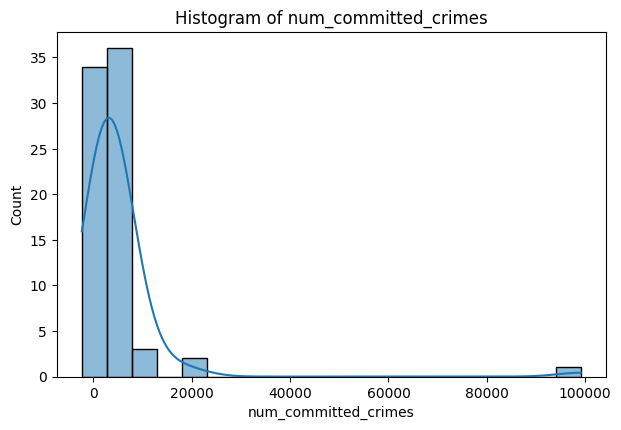

In [ ]:
plt.figure(figsize=(12, 8))
for column in suspicious_column:
    plt.subplot(2, 2, suspicious_column.index(column) + 1)
    sns.histplot(district[column], bins=20, kde=True)
    plt.title(f'Histogram of {column}')
plt.tight_layout()
plt.show()

### 12. Check for outliers in `trans` using the `describe` method, then look at the histograms of the suspicious columns

In [ ]:
trans.describe()

,trans_id,account_id,amount,balance,partner_account
count,1.056320e+06,1.056320e+06,1.056320e+06,1.056320e+06,1.056320e+06
mean,1.335311e+06,2.936867e+03,5.924146e+03,3.851833e+04,1.277068e+07
std,1.227487e+06,2.477345e+03,9.522735e+03,2.211787e+04,2.613658e+07
min,1.000000e+00,1.000000e+00,0.000000e+00,-4.112570e+04,-9.990000e+02
25%,4.302628e+05,1.204000e+03,1.359000e+02,2.240250e+04,-9.990000e+02
50%,8.585065e+05,2.434000e+03,2.100000e+03,3.314340e+04,-9.990000e+02
75%,2.060979e+06,3.660000e+03,6.800000e+03,4.960362e+04,3.410566e+06
max,3.682987e+06,1.138200e+04,8.740000e+04,2.096370e+05,9.999420e+07


In [ ]:
trans_suspicious_columns = ['amount']

#### Explore the outliers in the dataset

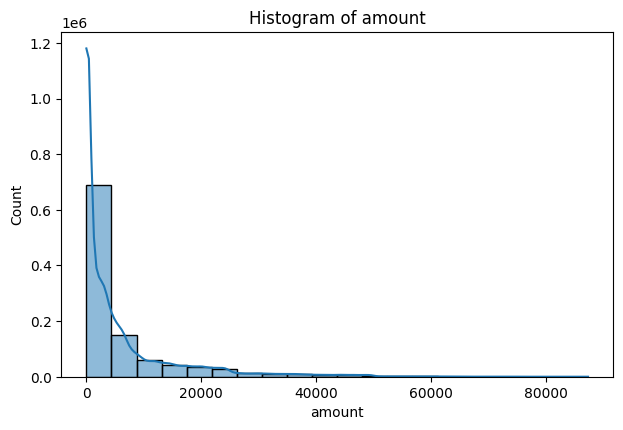

In [ ]:
plt.figure(figsize=(12, 8))
for columns in trans_suspicious_columns:
    plt.subplot(2, 2, trans_suspicious_columns.index(columns) + 1)
    sns.histplot(trans[columns], bins=20, kde=True)
    plt.title(f'Histogram of {columns}')
plt.tight_layout()
plt.show()

The DataFrame `account` doesn't have any columns that could have outliers, so we are not exploring it.

### 13. Merge (left join) `account` and `district` into a new DataFrame called `account_district` using their common columns

In [ ]:
account_district = account.merge(district, on='district_id', how='left')
print(account_district)

      account_id  district_id           frequency account_open_date  \
0            576           55  MONTHLY STATEMENTS        1993-01-01   
1           3818           74  MONTHLY STATEMENTS        1993-01-01   
2            704           55  MONTHLY STATEMENTS        1993-01-01   
3           2378           16  MONTHLY STATEMENTS        1993-01-01   
4           2632           24  MONTHLY STATEMENTS        1993-01-02   
...          ...          ...                 ...               ...   
4495         124           55  MONTHLY STATEMENTS        1997-12-28   
4496        3958           59  MONTHLY STATEMENTS        1997-12-28   
4497         777           30  MONTHLY STATEMENTS        1997-12-28   
4498        1573           63  MONTHLY STATEMENTS        1997-12-29   
4499        3276            1  MONTHLY STATEMENTS        1997-12-29   

      client_id      district_name         region  population  average_salary  \
0           692      BRNO - VENKOV  SOUTH MORAVIA    157042.0     

### 14. Check the information summary of `account_district`, any missing data?

In [ ]:
account_district.isna()

,account_id,district_id,frequency,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4495,False,False,False,False,False,False,False,False,False,False,False
4496,False,False,False,False,False,False,False,False,False,False,False
4497,False,False,False,False,False,False,False,False,False,False,False
4498,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
account_district.isna().sum()

account_id               0
district_id              0
frequency                0
account_open_date        0
client_id                0
district_name           40
region                  40
population              40
average_salary          40
unemployment_rate       40
num_committed_crimes    40
dtype: int64

#### Look at the rows with missing data in `account_district`

In [ ]:
rows_with_missing_data = account_district[account_district.isna().any(axis=1)]
print(rows_with_missing_data)

      account_id  district_id                     frequency account_open_date  \
5           1972           77            MONTHLY STATEMENTS        1993-01-02   
77          1000           77            MONTHLY STATEMENTS        1993-01-25   
308          299           77            MONTHLY STATEMENTS        1993-04-05   
322         8321           77            MONTHLY STATEMENTS        1993-04-12   
394          551           77            MONTHLY STATEMENTS        1993-05-07   
537         5228           77  STATEMENTS AFTER TRANSACTION        1993-06-23   
574          368           77            MONTHLY STATEMENTS        1993-07-06   
790         3157           77            MONTHLY STATEMENTS        1993-09-10   
817          857           77            MONTHLY STATEMENTS        1993-09-16   
832          153           77            MONTHLY STATEMENTS        1993-09-19   
902         4119           77            MONTHLY STATEMENTS        1993-10-18   
1161         742           7

#### Use `SimpleImputer` from `sklearn` to impute the missing data in columns `population`, `average_salary`, `unemployment_rate`, `num_committed_crimes` with their means

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
columns_for_imputation = ['population', 'average_salary', 'unemployment_rate', 'num_committed_crimes']

In [ ]:
district[columns_for_imputation].head()

,population,average_salary,unemployment_rate,num_committed_crimes
0,1204953.0,12541.000000,0.430000,99107.000000
1,88884.0,8814.106983,3.715258,2674.000000
2,75232.0,8980.000000,2.210000,2813.000000
3,149893.0,9753.000000,5.050000,6312.471883
4,95616.0,9307.000000,4.430000,1920.278654


In [ ]:
district[columns_for_imputation].isnull().mean()

population              0.0
average_salary          0.0
unemployment_rate       0.0
num_committed_crimes    0.0
dtype: float64

#### Use `fillna` method to impute the missing data in columns `district_name` and `region` with 'UNKNOWN'

In [ ]:
specific_cols = ['district_name', 'region']
account_district[specific_cols] = account_district[specific_cols].fillna('UNKNOWN')
account_district.head()

,account_id,district_id,frequency,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,576,55,MONTHLY STATEMENTS,1993-01-01,692,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0
1,3818,74,MONTHLY STATEMENTS,1993-01-01,4601,OSTRAVA - MESTO,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0
2,704,55,MONTHLY STATEMENTS,1993-01-01,844,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0
3,2378,16,MONTHLY STATEMENTS,1993-01-01,2873,JINDRICHUV HRADEC,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0
4,2632,24,MONTHLY STATEMENTS,1993-01-02,3177,KARLOVY VARY,WEST BOHEMIA,122603.0,8991.000000,2.01,5273.0


### 15. Merge (left join) `trans` and `account_district` into a new DataFrame called `all_data` using their common columns

In [ ]:
all_data = trans.merge(account_district, on='account_id', how='left')
all_data.head()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,district_id,frequency,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,16,MONTHLY STATEMENTS,1993-01-01,2873,JINDRICHUV HRADEC,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,55,MONTHLY STATEMENTS,1993-01-01,692,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,55,MONTHLY STATEMENTS,1993-01-01,844,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,74,MONTHLY STATEMENTS,1993-01-01,4601,OSTRAVA - MESTO,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,77,MONTHLY STATEMENTS,1993-01-02,2397,UNKNOWN,UNKNOWN,NaN,NaN,NaN,NaN


#### Check the information summary of `all_data`

In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1056320 entries, 0 to 1056319
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   trans_id              1056320 non-null  int64         
 1   account_id            1056320 non-null  int64         
 2   date                  1056320 non-null  datetime64[ns]
 3   type                  1056320 non-null  object        
 4   operation_type        1056320 non-null  object        
 5   amount                1056320 non-null  float64       
 6   balance               1056320 non-null  float64       
 7   description           1056320 non-null  object        
 8   partner_bank          1056320 non-null  object        
 9   partner_account       1056320 non-null  float64       
 10  district_id           1056320 non-null  int64         
 11  frequency             1056320 non-null  object        
 12  account_open_date     1056320 non-null  da

### 16. Create a new column `account_open_year` and assign it as the year from column `account_open_date`

In [ ]:
all_data['account_open_date'] = pd.to_datetime(all_data['account_open_date'])
all_data['account_open_year'] = all_data['account_open_date'].dt.year

In [ ]:
all_data.head()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,...,frequency,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes,account_open_year
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,...,MONTHLY STATEMENTS,1993-01-01,2873,JINDRICHUV HRADEC,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0,1993
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,...,MONTHLY STATEMENTS,1993-01-01,692,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,...,MONTHLY STATEMENTS,1993-01-01,844,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,MONTHLY STATEMENTS,1993-01-01,4601,OSTRAVA - MESTO,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0,1993
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,...,MONTHLY STATEMENTS,1993-01-02,2397,UNKNOWN,UNKNOWN,NaN,NaN,NaN,NaN,1993


### 17. Calculate the difference between columns `date` (transaction date) and `account_open_date`

In [ ]:
all_data.dtypes

trans_id                         int64
account_id                       int64
date                    datetime64[ns]
type                            object
operation_type                  object
amount                         float64
balance                        float64
description                     object
partner_bank                    object
partner_account                float64
district_id                      int64
frequency                       object
account_open_date       datetime64[ns]
client_id                        int64
district_name                   object
region                          object
population                     float64
average_salary                 float64
unemployment_rate              float64
num_committed_crimes           float64
account_open_year                int64
dtype: object

In [ ]:
all_data['date_account_open_diff'] = (all_data['date'] - all_data['account_open_date']).dt.days

In [ ]:
all_data.head()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,...,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes,account_open_year,date_account_open_diff
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,...,1993-01-01,2873,JINDRICHUV HRADEC,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0,1993,0
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,...,1993-01-01,692,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993,0
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,...,1993-01-01,844,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993,0
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,1993-01-01,4601,OSTRAVA - MESTO,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0,1993,0
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,...,1993-01-02,2397,UNKNOWN,UNKNOWN,NaN,NaN,NaN,NaN,1993,0


### 18. Create a new column `account_age_days` and assign it as the difference in days between columns `date` (transaction date) and `account_open_date`

In [ ]:
all_data['account_age_days'] = (all_data['date'] - all_data['account_open_date']).dt.days
all_data.head()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,...,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes,account_open_year,date_account_open_diff,account_age_days
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,...,2873,JINDRICHUV HRADEC,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0,1993,0,0
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,...,692,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993,0,0
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,...,844,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993,0,0
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,4601,OSTRAVA - MESTO,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0,1993,0,0
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,...,2397,UNKNOWN,UNKNOWN,NaN,NaN,NaN,NaN,1993,0,0


### 19. Create a new column `amount_category` by cutting the column `amount` into 3 equal-sized bins, and label the bins as 'low_amount', 'medium_amount', 'high_amount'

In [ ]:
bin_edges = pd.cut(all_data['amount'], bins=3, labels=['low_amount', 'medium_amount', 'high_amount'])

In [ ]:
all_data['amount_category'] = bin_edges

In [ ]:
all_data.head()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,...,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes,account_open_year,date_account_open_diff,account_age_days,amount_category
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,...,JINDRICHUV HRADEC,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0,1993,0,0,low_amount
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,...,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993,0,0,low_amount
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,...,BRNO - VENKOV,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993,0,0,low_amount
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,OSTRAVA - MESTO,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0,1993,0,0,low_amount
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,...,UNKNOWN,UNKNOWN,NaN,NaN,NaN,NaN,1993,0,0,low_amount


#### Verify the categories and their counts in `amount_category`

In [ ]:
all_data['amount_category'].value_counts()

low_amount       1013033
medium_amount      41336
high_amount         1951
Name: amount_category, dtype: int64

### 20. Create a new column `account_age_days_category` by cutting the column `account_age_days` into 5 equal-width bins

In [ ]:
bin_edges_account_age_days = pd.cut(all_data['account_age_days'], bins=5, labels=False, precision=0)

In [ ]:
all_data['account_age_days_category'] = bin_edges_account_age_days

In [ ]:
all_data.head()

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,...,region,population,average_salary,unemployment_rate,num_committed_crimes,account_open_year,date_account_open_diff,account_age_days,amount_category,account_age_days_category
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,...,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0,1993,0,0,low_amount,0
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,...,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993,0,0,low_amount,0
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,...,SOUTH MORAVIA,157042.0,9071.985413,2.43,3894.0,1993,0,0,low_amount,0
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0,1993,0,0,low_amount,0
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,...,UNKNOWN,NaN,NaN,NaN,NaN,1993,0,0,low_amount,0


#### Verify the categories and their counts in `account_age_days_category`

In [ ]:
all_data['account_age_days_category'].value_counts()

1    333012
0    330815
2    204014
3    131926
4     56553
Name: account_age_days_category, dtype: int64

#### Print out the first 20 rows of `all_data` to look at the newly added columns

In [ ]:
all_data.head(20)

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,...,region,population,average_salary,unemployment_rate,num_committed_crimes,account_open_year,date_account_open_diff,account_age_days,amount_category,account_age_days_category
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,...,SOUTH BOHEMIA,93931.0,8427.000000,1.540000,1913.0,1993,0,0,low_amount,0
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,...,SOUTH MORAVIA,157042.0,9071.985413,2.430000,3894.0,1993,0,0,low_amount,0
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,...,SOUTH MORAVIA,157042.0,9071.985413,2.430000,3894.0,1993,0,0,low_amount,0
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,NORTH MORAVIA,323870.0,10673.000000,5.440000,18347.0,1993,0,0,low_amount,0
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,...,UNKNOWN,NaN,NaN,NaN,NaN,1993,0,0,low_amount,0
5,771035,2632,1993-01-02,CREDIT,CREDIT IN CASH,1100.0,1100.0,UNKNOWN,UNKNOWN,-999.0,...,WEST BOHEMIA,122603.0,8991.000000,2.010000,5273.0,1993,0,0,low_amount,0
6,452728,1539,1993-01-03,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,...,PRAGUE,1204953.0,12541.000000,0.430000,99107.0,1993,0,0,low_amount,0
7,725751,2484,1993-01-03,CREDIT,CREDIT IN CASH,1100.0,1100.0,UNKNOWN,UNKNOWN,-999.0,...,NORTH MORAVIA,323870.0,10673.000000,5.440000,18347.0,1993,0,0,low_amount,0
8,497211,1695,1993-01-03,CREDIT,CREDIT IN CASH,200.0,200.0,UNKNOWN,UNKNOWN,-999.0,...,NORTH MORAVIA,127369.0,8369.000000,3.856513,2807.0,1993,0,0,low_amount,0
9,232960,793,1993-01-03,CREDIT,CREDIT IN CASH,800.0,800.0,UNKNOWN,UNKNOWN,-999.0,...,EAST BOHEMIA,162580.0,9538.000000,4.374013,5410.0,1993,0,0,low_amount,0
